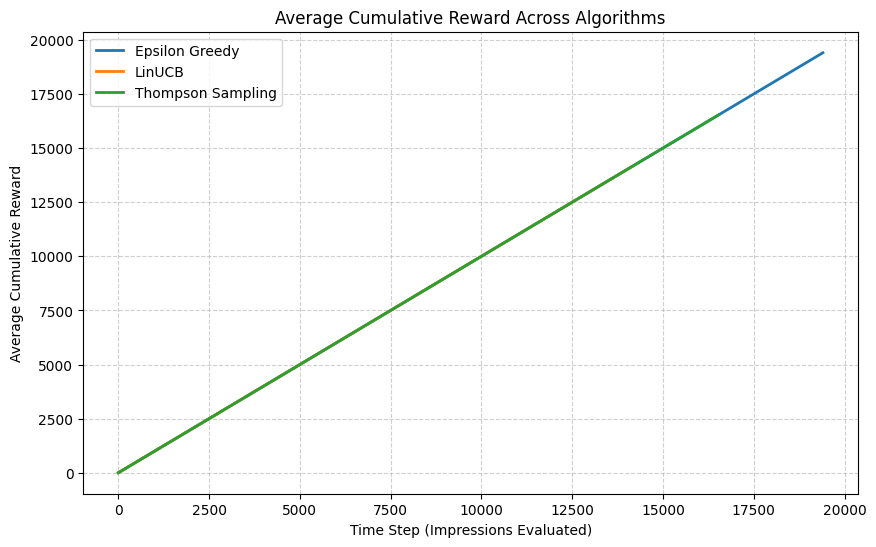

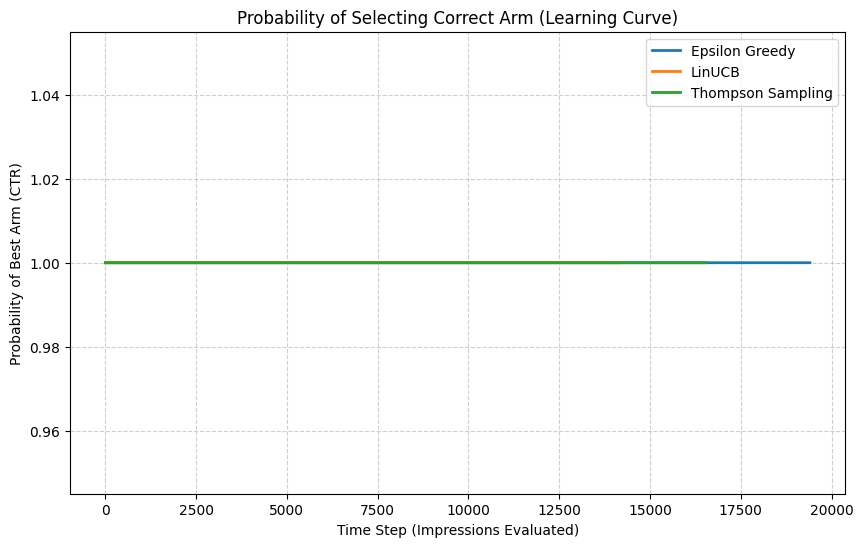

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
# Map the filenames to the Algorithm names so we don't get a KeyError
file_map = {
    "results_eps.csv": "Epsilon Greedy",
    "results_linucb.csv": "LinUCB",
    "results_ts.csv": "Thompson Sampling"
}

all_results = []

for filename, algo_name in file_map.items():
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        
        # Inject the 'Algorithm' column dynamically based on the filename
        df["Algorithm"] = algo_name
        
        # Ensure the column used for grouping is named "Simulation"
        if "run" in df.columns and "Simulation" not in df.columns:
            df.rename(columns={"run": "Simulation"}, inplace=True)
        elif "Simulation" not in df.columns:
            df["Simulation"] = 0
            
        all_results.append(df)
    else:
        print(f"Warning: {filename} not found in the directory.")

if not all_results:
    raise ValueError("No result files found! Please ensure the CSVs are in the same folder as this notebook.")

# Combine into one master dataframe
result_df = pd.concat(all_results, ignore_index=True)

# Sort chronologically to ensure accurate cumulative math
result_df = result_df.sort_values(["Algorithm", "Simulation", "Timestep"])

# ==========================================
# 2. CUMULATIVE REWARD PLOT
# ==========================================
# Average the cumulative reward across all simulations (0 through 9)
avg_cum_reward = (
    result_df.groupby(["Algorithm", "Timestep"])["Cumulative_Reward"]
    .mean().reset_index()
)

plt.figure(figsize=(10, 6))
for algo in avg_cum_reward["Algorithm"].unique():
    data = avg_cum_reward[avg_cum_reward["Algorithm"] == algo]
    plt.plot(data["Timestep"], data["Cumulative_Reward"], label=algo, linewidth=2)

plt.xlabel("Time Step (Impressions Evaluated)")
plt.ylabel("Average Cumulative Reward")
plt.title("Average Cumulative Reward Across Algorithms")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==========================================
# 3. PROBABILITY OF BEST ARM (CTR) PLOT
# ==========================================
# Probability = Total Reward so far / Total Steps so far
result_df["Prob_Best_Arm"] = result_df["Cumulative_Reward"] / result_df["Timestep"]

# Average the probability (CTR) across all simulations
avg_prob = (
    result_df.groupby(["Algorithm", "Timestep"])["Prob_Best_Arm"]
    .mean().reset_index()
)

plt.figure(figsize=(10, 6))
for algo in avg_prob["Algorithm"].unique():
    data = avg_prob[avg_prob["Algorithm"] == algo]
    plt.plot(data["Timestep"], data["Prob_Best_Arm"], label=algo, linewidth=2)

plt.xlabel("Time Step (Impressions Evaluated)")
plt.ylabel("Probability of Best Arm (CTR)")
plt.title("Probability of Selecting Correct Arm (Learning Curve)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()